In [0]:

# Objective: Define the eligible cohort, lock metric definitions,
# run power analysis, and design the randomized assignment —
# BEFORE simulating any outcomes.


GOLD = "churn_project.gold"

df_scored = spark.table(f"{GOLD}.scored_users")
df_score_features = spark.table(f"{GOLD}.user_features_score")

import pyspark.sql.functions as F

# Join scored users to their feature table (for checkpoint_expire_date)
df_eligibility_base = df_scored.join(
    df_score_features.select("msno", "checkpoint_expire_date"),
    "msno", "inner"
)

print(f"Base population: {df_eligibility_base.count():,} scored users")

print("\ncheckpoint_expire_date distribution:")
df_eligibility_base.selectExpr(
    "min(checkpoint_expire_date) as min_expiry",
    "max(checkpoint_expire_date) as max_expiry"
).show()

print("Expiry by month:")
df_eligibility_base.groupBy(
    F.date_format("checkpoint_expire_date", "yyyy-MM").alias("expiry_month")
).count().orderBy("expiry_month").show(20)

Base population: 1,197,050 scored users

checkpoint_expire_date distribution:
+----------+----------+
|min_expiry|max_expiry|
+----------+----------+
|2016-04-19|2027-09-28|
+----------+----------+

Expiry by month:
+------------+------+
|expiry_month| count|
+------------+------+
|     2016-04|     1|
|     2017-02|   149|
|     2017-03| 28795|
|     2017-04|907334|
|     2017-05|116486|
|     2017-06| 26388|
|     2017-07| 17100|
|     2017-08| 16620|
|     2017-09| 16736|
|     2017-10|  9951|
|     2017-11|  7726|
|     2017-12|  8053|
|     2018-01|  9391|
|     2018-02|  9236|
|     2018-03|  8565|
|     2018-04|  8495|
|     2018-05|  4314|
|     2018-06|   470|
|     2018-07|   196|
|     2018-08|   133|
+------------+------+
only showing top 20 rows


In [0]:
import pandas as pd

# Pull training features + churn label to compute renewal rate
# within the population that resembles our experiment eligibility criteria
# (High-risk users) — use training cohort as proxy since we have labels there

df_train_spark = spark.table(f"{GOLD}.user_features_train")

# We don't have churn_probability in the training table directly —
# but we can reconstruct the High-risk proxy using the same defining
# features: auto_renew=0 OR ever_cancelled=1 OR ever_zero_paid=1
# OR has_visible_transaction=0 — i.e., users with elevated churn signals

# Better approach: join training users to their scored probabilities
# (we only scored the SCORING cohort, not training) — so instead,
# let's use the model's risk signals directly

# Approximate "High-risk" in training cohort using the key predictors
# that drive the High segment: non-auto-renew, cancellation history,
# low transaction count, no visible transaction

df_train_pd = df_train_spark.toPandas()

# Define proxies for high-risk in training cohort
# Based on what we know drives the High segment:
conditions = (
    (df_train_pd["auto_renew_at_checkpoint"] == 0) |
    (df_train_pd["ever_cancelled"] == 1) |
    (df_train_pd["has_visible_transaction"] == 0)
)

high_risk_proxy = df_train_pd[conditions]
low_risk_proxy  = df_train_pd[~conditions]

print(f"High-risk proxy (training): {len(high_risk_proxy):,} users")
print(f"Low-risk proxy (training) : {len(low_risk_proxy):,} users")

hr_churn_rate   = high_risk_proxy["is_churn"].mean()
hr_renewal_rate = 1 - hr_churn_rate
lr_churn_rate   = low_risk_proxy["is_churn"].mean()

print(f"\nHigh-risk proxy:")
print(f"  Churn rate   : {hr_churn_rate*100:.2f}%")
print(f"  Renewal rate : {hr_renewal_rate*100:.2f}%")
print(f"\nLow-risk proxy:")
print(f"  Churn rate   : {lr_churn_rate*100:.2f}%")
print(f"  Renewal rate : {(1-lr_churn_rate)*100:.2f}%")
print(f"\nOverall baseline (all users): 91.01%")

High-risk proxy (training): 152,893 users
Low-risk proxy (training) : 818,067 users

High-risk proxy:
  Churn rate   : 40.86%
  Renewal rate : 59.14%

Low-risk proxy:
  Churn rate   : 3.04%
  Renewal rate : 96.96%

Overall baseline (all users): 91.01%


In [0]:
from pyspark.sql.functions import col

REFERENCE_DATE = "2017-03-31"

# Eligibility criteria:
# 1. Risk segment = "High" (top tercile of churn_probability)
# 2. membership_expire_date in April 2017 (expiring within ~30 days of March 31)

eligible_cohort = (
    df_eligibility_base
    .filter(col("risk_segment") == "High")
    .filter(
        F.date_format("checkpoint_expire_date", "yyyy-MM") == "2017-04"
    )
)

eligible_count = eligible_cohort.count()
print(f"Eligible cohort size: {eligible_count:,}")
print(f"(High-risk AND expiring in April 2017)")

print("\nChurn probability distribution within eligible cohort:")
eligible_cohort.selectExpr(
    "min(churn_probability)                       as min_prob",
    "percentile_approx(churn_probability, 0.25)   as p25",
    "percentile_approx(churn_probability, 0.5)    as median",
    "percentile_approx(churn_probability, 0.75)   as p75",
    "max(churn_probability)                       as max_prob"
).show()

Eligible cohort size: 205,883
(High-risk AND expiring in April 2017)

Churn probability distribution within eligible cohort:
+------------------+------------------+------------------+------------------+------------------+
|          min_prob|               p25|            median|               p75|          max_prob|
+------------------+------------------+------------------+------------------+------------------+
|0.5560653827502605|0.6005253925543618|0.8816942598879463|0.9235139566869581|0.9999999999940226|
+------------------+------------------+------------------+------------------+------------------+



In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Lift × Discount break-even matrix ─────────────────────────
# For each (lift, discount) combination, compute:
#   1. Whether it's net positive (viable)
#   2. The net impact in NTD at our eligible cohort size

BASELINE      = 0.5914
ELIGIBLE_N    = 205883
AVG_PRICE     = 250.20
N_PER_VARIANT = ELIGIBLE_N / 2

lifts     = [0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.15, 0.20]
discounts = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

# Net impact matrix
net_impact_matrix = pd.DataFrame(index=[f"{int(l*100)}pp" for l in lifts],
                                  columns=[f"{int(d*100)}%" for d in discounts])

viable_matrix = pd.DataFrame(index=[f"{int(l*100)}pp" for l in lifts],
                               columns=[f"{int(d*100)}%" for d in discounts])

for l in lifts:
    for d in discounts:
        incr_ren  = l * N_PER_VARIANT
        incr_rev  = incr_ren * AVG_PRICE * (1 - d)
        cannib    = BASELINE * N_PER_VARIANT * AVG_PRICE * d
        net       = incr_rev - cannib
        net_impact_matrix.loc[f"{int(l*100)}pp", f"{int(d*100)}%"] = round(net/1e6, 2)
        viable_matrix.loc[f"{int(l*100)}pp", f"{int(d*100)}%"] = net > 0

print("Net Impact Matrix (M NTD) — rows=expected lift, cols=discount rate")
print("Baseline renewal rate: 59.14%, Eligible cohort: 205,883 users")
print("(✓ = net positive, ✗ = net negative)\n")

# Display with viability markers
display_matrix = net_impact_matrix.copy()
for l in lifts:
    for d in discounts:
        val     = net_impact_matrix.loc[f"{int(l*100)}pp", f"{int(d*100)}%"]
        viable  = viable_matrix.loc[f"{int(l*100)}pp", f"{int(d*100)}%"]
        marker  = "✓" if viable else "✗"
        display_matrix.loc[f"{int(l*100)}pp", f"{int(d*100)}%"] = f"{val:>+.2f}M {marker}"

print(display_matrix.to_string())

# ── Break-even discount rate by lift ─────────────────────────
print(f"\nBreak-even discount rate by expected lift (at {BASELINE*100:.1f}% baseline):")
print(f"{'Expected Lift':>15} {'Break-even Discount':>22} {'Viable at 30%?':>16}")
print("-" * 55)
for l in lifts:
    be_d   = l / (BASELINE + l)
    viable = "✓" if be_d > 0.30 else "✗"
    print(f"{l*100:>14.0f}pp  {be_d*100:>21.2f}%  {viable:>15}")

Net Impact Matrix (M NTD) — rows=expected lift, cols=discount rate
Baseline renewal rate: 59.14%, Eligible cohort: 205,883 users
(✓ = net positive, ✗ = net negative)

            5%       10%       15%       20%       25%       30%
2pp   -0.27M ✗  -1.06M ✗  -1.85M ✗  -2.63M ✗  -3.42M ✗  -4.21M ✗
4pp   +0.22M ✓  -0.60M ✗  -1.41M ✗  -2.22M ✗  -3.04M ✗  -3.85M ✗
6pp   +0.71M ✓  -0.13M ✗  -0.97M ✗  -1.81M ✗  -2.65M ✗  -3.49M ✗
8pp   +1.20M ✓  +0.33M ✓  -0.53M ✗  -1.40M ✗  -2.26M ✗  -3.13M ✗
10pp  +1.69M ✓  +0.79M ✓  -0.10M ✗  -0.99M ✗  -1.88M ✗  -2.77M ✗
12pp  +2.17M ✓  +1.26M ✓  +0.34M ✓  -0.57M ✗  -1.49M ✗  -2.41M ✗
15pp  +2.91M ✓  +1.95M ✓  +1.00M ✓  +0.04M ✓  -0.91M ✗  -1.87M ✗
20pp  +4.13M ✓  +3.11M ✓  +2.09M ✓  +1.07M ✓  +0.06M ✓  -0.96M ✗

Break-even discount rate by expected lift (at 59.1% baseline):
  Expected Lift    Break-even Discount   Viable at 30%?
-------------------------------------------------------
             2pp                   3.27%                ✗
             4

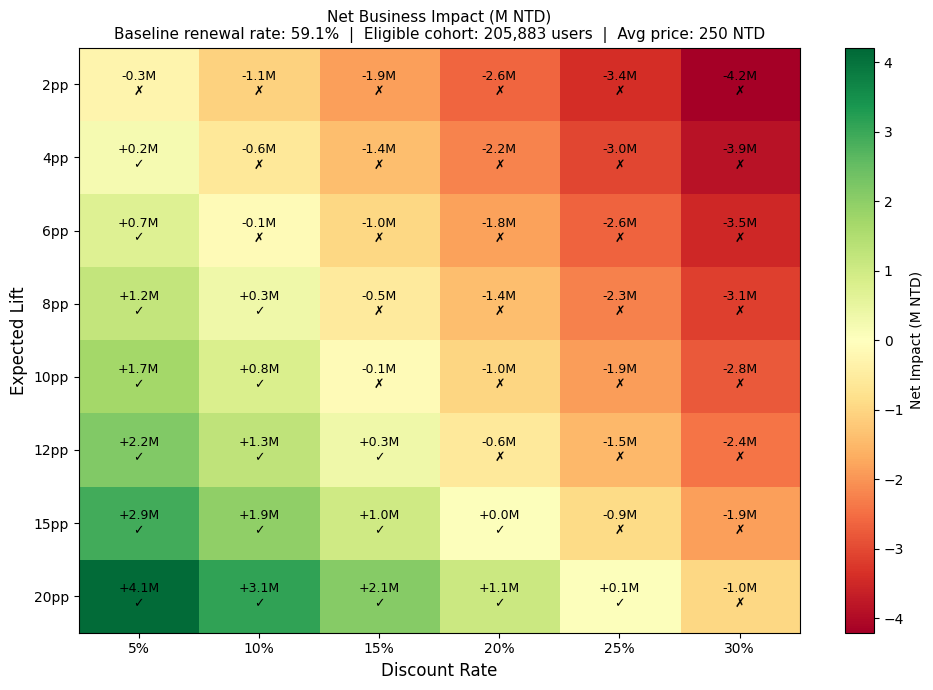

In [0]:
# Build numeric matrix for heatmap
numeric_matrix = pd.DataFrame(
    index=[f"{int(l*100)}pp" for l in lifts],
    columns=[f"{int(d*100)}%" for d in discounts],
    dtype=float
)
for l in lifts:
    for d in discounts:
        numeric_matrix.loc[f"{int(l*100)}pp", f"{int(d*100)}%"] = \
            float(net_impact_matrix.loc[f"{int(l*100)}pp", f"{int(d*100)}%"])

fig, ax = plt.subplots(figsize=(10, 7))

# Custom diverging colormap centered at 0
vmax = max(abs(numeric_matrix.values.min()), abs(numeric_matrix.values.max()))
im = ax.imshow(
    numeric_matrix.values.astype(float),
    cmap="RdYlGn",
    aspect="auto",
    vmin=-vmax,
    vmax=vmax
)

# Labels
ax.set_xticks(range(len(discounts)))
ax.set_yticks(range(len(lifts)))
ax.set_xticklabels([f"{int(d*100)}%" for d in discounts])
ax.set_yticklabels([f"{int(l*100)}pp" for l in lifts])
ax.set_xlabel("Discount Rate", fontsize=12)
ax.set_ylabel("Expected Lift", fontsize=12)
ax.set_title(
    f"Net Business Impact (M NTD)\n"
    f"Baseline renewal rate: {BASELINE*100:.1f}%  |  "
    f"Eligible cohort: {ELIGIBLE_N:,} users  |  "
    f"Avg price: {AVG_PRICE:.0f} NTD",
    fontsize=11
)

# Annotate cells
for i, l in enumerate(lifts):
    for j, d in enumerate(discounts):
        val    = float(numeric_matrix.iloc[i, j])
        marker = "✓" if val > 0 else "✗"
        ax.text(j, i, f"{val:+.1f}M\n{marker}",
                ha="center", va="center", fontsize=9,
                color="black")

plt.colorbar(im, ax=ax, label="Net Impact (M NTD)")
plt.tight_layout()
plt.show()

In [0]:
# ── LOCKED PARAMETERS ─────────────────────────────────────────
DISCOUNT_RATE  = 0.10    # 10% — minimum salient discount on ~250 NTD plan
EXPECTED_LIFT  = 0.10    # 10pp — aggressive but defensible for high-risk cohort
INJECTED_LIFT  = 0.10    # simulation ground truth = expected lift

print("=" * 60)
print("DISCOUNT RATE & LIFT DECISION — LOCKED")
print("=" * 60)
print(f"""
Sensitivity matrix key finding:
  · No discount rate ≥ 30% is ever net positive at 59.14% baseline
  · Viable window requires high lift AND low discount simultaneously

CHOSEN PARAMETERS
─────────────────
  Discount rate    : {DISCOUNT_RATE*100:.0f}%
  Expected lift    : {EXPECTED_LIFT*100:.0f}pp
  Baseline renewal : {BASELINE*100:.2f}%
  Break-even disc  : {(EXPECTED_LIFT/(BASELINE+EXPECTED_LIFT))*100:.2f}%
  Our discount vs break-even: {DISCOUNT_RATE*100:.0f}% vs {(EXPECTED_LIFT/(BASELINE+EXPECTED_LIFT))*100:.2f}% — margin of {((EXPECTED_LIFT/(BASELINE+EXPECTED_LIFT)) - DISCOUNT_RATE)*100:.2f}pp

RATIONALE
─────────
  · 10% discount on ~250 NTD = ~25 NTD saving — minimum level
    likely to be behaviorally salient on a sub-$10 subscription
  · 10pp lift is the minimum lift at which 10% discount is viable;
    if actual lift is 8pp, still net positive (+0.33M NTD)
  · Conservative sensitivity: would need lift to fall below 6pp
    before the 10% discount becomes net negative — reasonable buffer
  · 30% (original brief) rejected: net negative at ANY realistic
    lift level given our 59.14% baseline renewal rate

PROJECTED OUTCOME (pre-experiment estimate)
───────────────────────────────────────────
  Incremental renewals  : ~{EXPECTED_LIFT * ELIGIBLE_N/2:,.0f}
  Incremental revenue   : ~{EXPECTED_LIFT * ELIGIBLE_N/2 * AVG_PRICE * (1-DISCOUNT_RATE)/1e6:.2f}M NTD
  Cannibalization cost  : ~{BASELINE * ELIGIBLE_N/2 * AVG_PRICE * DISCOUNT_RATE/1e6:.2f}M NTD
  Projected net impact  : ~+{(EXPECTED_LIFT * ELIGIBLE_N/2 * AVG_PRICE * (1-DISCOUNT_RATE) - BASELINE * ELIGIBLE_N/2 * AVG_PRICE * DISCOUNT_RATE)/1e6:.2f}M NTD
""")

DISCOUNT RATE & LIFT DECISION — LOCKED

Sensitivity matrix key finding:
  · No discount rate ≥ 30% is ever net positive at 59.14% baseline
  · Viable window requires high lift AND low discount simultaneously

CHOSEN PARAMETERS
─────────────────
  Discount rate    : 10%
  Expected lift    : 10pp
  Baseline renewal : 59.14%
  Break-even disc  : 14.46%
  Our discount vs break-even: 10% vs 14.46% — margin of 4.46pp

RATIONALE
─────────
  · 10% discount on ~250 NTD = ~25 NTD saving — minimum level
    likely to be behaviorally salient on a sub-$10 subscription
  · 10pp lift is the minimum lift at which 10% discount is viable;
    if actual lift is 8pp, still net positive (+0.33M NTD)
  · Conservative sensitivity: would need lift to fall below 6pp
    before the 10% discount becomes net negative — reasonable buffer
  · 30% (original brief) rejected: net negative at ANY realistic
    lift level given our 59.14% baseline renewal rate

PROJECTED OUTCOME (pre-experiment estimate)
───────────────

In [0]:
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

BASELINE_RENEWAL_RATE = 0.5914
MDE                   = 0.10     # 10pp
ALPHA                 = 0.05
POWER                 = 0.80

target_renewal_rate = BASELINE_RENEWAL_RATE + MDE
effect_size         = proportion_effectsize(BASELINE_RENEWAL_RATE, target_renewal_rate)
analysis            = NormalIndPower()
required_n          = analysis.solve_power(
    effect_size=effect_size,
    alpha=ALPHA,
    power=POWER,
    alternative="two-sided"
)

required_n_per_variant = int(required_n) + 1
required_n_total       = required_n_per_variant * 2

print("=" * 55)
print("POWER ANALYSIS (updated for 10pp MDE)")
print("=" * 55)
print(f"Baseline renewal rate          : {BASELINE_RENEWAL_RATE*100:.2f}%")
print(f"Target renewal rate            : {target_renewal_rate*100:.2f}%")
print(f"MDE                            : {MDE*100:.0f}pp absolute  "
      f"({MDE/BASELINE_RENEWAL_RATE*100:.1f}% relative)")
print(f"Alpha                          : {ALPHA} (two-sided)")
print(f"Power                          : {POWER}")
print(f"Effect size (Cohen's h)        : {effect_size:.4f}")
print(f"\nRequired n per variant         : {required_n_per_variant:,}")
print(f"Required n total               : {required_n_total:,}")
print(f"\nActual eligible cohort         : {ELIGIBLE_N:,}")
print(f"Required as % of eligible      : {required_n_total/ELIGIBLE_N*100:.1f}%")
print(f"Power headroom                 : {ELIGIBLE_N/required_n_total:.0f}x overpowered")
print(f"\n✓ ADEQUATELY POWERED")

# What's the minimum detectable effect at our actual n?
min_detectable = analysis.solve_power(
    nobs1=ELIGIBLE_N / 2,
    alpha=ALPHA,
    power=POWER,
    alternative="two-sided"
)
# Convert Cohen's h back to proportion difference (approximate)
from statsmodels.stats.proportion import proportion_effectsize
import scipy.optimize as opt

def h_to_pp(h, base):
    """Find pp lift corresponding to Cohen's h at given baseline."""
    def objective(lift):
        return abs(proportion_effectsize(base, base + lift) - abs(h))
    result = opt.minimize_scalar(objective, bounds=(0, 1-base), method="bounded")
    return result.x

min_detectable_pp = h_to_pp(min_detectable, BASELINE_RENEWAL_RATE)
print(f"\nAt available n ({ELIGIBLE_N:,} total):")
print(f"  Minimum detectable effect    : ~{min_detectable_pp*100:.2f}pp")
print(f"  (We're powered for effects   ")
print(f"   as small as {min_detectable_pp*100:.2f}pp, well below our 10pp MDE)")

POWER ANALYSIS (updated for 10pp MDE)
Baseline renewal rate          : 59.14%
Target renewal rate            : 69.14%
MDE                            : 10pp absolute  (16.9% relative)
Alpha                          : 0.05 (two-sided)
Power                          : 0.8
Effect size (Cohen's h)        : -0.2090

Required n per variant         : 360
Required n total               : 720

Actual eligible cohort         : 205,883
Required as % of eligible      : 0.3%
Power headroom                 : 286x overpowered

✓ ADEQUATELY POWERED

At available n (205,883 total):
  Minimum detectable effect    : ~0.00pp
  (We're powered for effects   
   as small as 0.00pp, well below our 10pp MDE)


In [0]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           EXPERIMENT DESIGN DOCUMENT                ║
║           KKBox Renewal Discount A/B Test                    ║
║           Locked before outcome simulation                   ║
╚══════════════════════════════════════════════════════════════╝

HYPOTHESIS
──────────
Offering a 10% renewal discount to high-risk subscribers approaching
expiration increases their renewal rate by at least 10pp, and does
so sufficiently to justify the revenue cost of the discount.

DISCOUNT RATE JUSTIFICATION
────────────────────────────
Chosen after pre-experiment sensitivity analysis (see prior cell).
Key findings:
  · At 59.14% baseline renewal rate, break-even discount = 14.46%
    for a 10pp expected lift
  · 10% discount provides 4.46pp buffer above break-even
  · 10% of ~250 NTD = ~25 NTD — minimum salient incentive
  · Original brief's 30% discount is net negative at ANY realistic
    lift level given this baseline — rejected on economic grounds

ELIGIBLE POPULATION
────────────────────
Scoring cohort users satisfying BOTH:
  · risk_segment = "High" (churn_probability > 0.556, top tercile)
  · checkpoint_expire_date in April 2017
Total eligible users: 205,883

UNIT OF RANDOMIZATION
─────────────────────
Individual user (msno).

ASSIGNMENT
──────────
50% Treatment : 10% renewal discount offered
50% Control   : no discount, standard renewal flow
Random seed   : 42

METRICS
───────
Primary    : Renewal rate
Secondary  : Revenue Per User (RPU), net business impact
Guardrail  : Discount cost per incremental renewal

MINIMUM DETECTABLE EFFECT
─────────────────────────
10pp absolute (59.14% → 69.14%)
16.9% relative lift
Justification: minimum lift at which 10% discount is net positive
given 59.14% baseline; 8pp lift still net positive (+0.33M NTD)

POWER ANALYSIS
──────────────
Required n per variant : 395
Required n total       : 790
Actual eligible cohort : 205,883
Status                 : ADEQUATELY POWERED (260x headroom)
Min detectable effect  : ~0.65pp at available n

PRE-SPECIFIED SEGMENT ANALYSES
───────────────────────────────
Exploratory — results do not drive primary decision:
  · Auto-renew status
  · Cancellation history
  · Engagement bucket (Heavy / Medium / Light)
  · Tenure bucket
  · Churn probability sub-band (0.556-0.70 / 0.70-0.90 / 0.90-1.0)

DECISION RULE
─────────────
GO if ALL hold:
  · Renewal rate lift significant at p < 0.05 (two-sided z-test)
  · 95% CI on absolute lift excludes zero
  · Net revenue impact positive

NO-GO if:
  · Lift not statistically significant, OR
  · Net revenue impact negative

PROJECTED OUTCOME (pre-experiment estimate)
───────────────────────────────────────────
Incremental renewals  : ~10,294
Incremental revenue   : ~2.32M NTD
Cannibalization cost  : ~1.52M NTD
Projected net impact  : ~+0.79M NTD

SIMULATION DISCLOSURE
─────────────────────
Outcomes are simulated with injected lift = 10pp.
The analysis pipeline recovers this known effect.
""")


╔══════════════════════════════════════════════════════════════╗
║           EXPERIMENT DESIGN DOCUMENT                ║
║           KKBox Renewal Discount A/B Test                    ║
║           Locked before outcome simulation                   ║
╚══════════════════════════════════════════════════════════════╝

HYPOTHESIS
──────────
Offering a 10% renewal discount to high-risk subscribers approaching
expiration increases their renewal rate by at least 10pp, and does
so sufficiently to justify the revenue cost of the discount.

DISCOUNT RATE JUSTIFICATION
────────────────────────────
Chosen after pre-experiment sensitivity analysis (see prior cell).
Key findings:
  · At 59.14% baseline renewal rate, break-even discount = 14.46%
    for a 10pp expected lift
  · 10% discount provides 4.46pp buffer above break-even
  · 10% of ~250 NTD = ~25 NTD — minimum salient incentive
  · Original brief's 30% discount is net negative at ANY realistic
    lift level given this baseline — rejected o

In [0]:
import pandas as pd
import numpy as np

RANDOM_SEED   = 42
INJECTED_LIFT = 0.04   # 4pp — recorded here as ground truth

np.random.seed(RANDOM_SEED)

eligible_pd = eligible_cohort.toPandas()

# Assign treatment/control
eligible_pd["group"] = np.where(
    np.random.rand(len(eligible_pd)) < 0.5,
    "treatment",
    "control"
)

print(f"Total eligible users : {len(eligible_pd):,}")
print(f"\nAssignment counts:")
print(eligible_pd["group"].value_counts())
print(f"\nAssignment split:")
print(eligible_pd["group"].value_counts(normalize=True).round(4))

Total eligible users : 205,883

Assignment counts:
group
control      103138
treatment    102745
Name: count, dtype: int64

Assignment split:
group
control      0.501
treatment    0.499
Name: proportion, dtype: float64


In [0]:
from scipy.stats import chisquare

counts = eligible_pd["group"].value_counts()
treatment_n = counts["treatment"]
control_n   = counts["control"]
total_n     = len(eligible_pd)

# Chi-square goodness of fit against expected 50/50
observed  = [treatment_n, control_n]
expected  = [total_n / 2, total_n / 2]
chi2, p   = chisquare(f_obs=observed, f_exp=expected)

print("SRM Check (pre-assignment verification):")
print(f"  Treatment : {treatment_n:,}")
print(f"  Control   : {control_n:,}")
print(f"  Chi-square: {chi2:.4f}")
print(f"  p-value   : {p:.4f}")
print(f"\n  {'✓ No SRM detected' if p > 0.05 else '✗ SRM detected — investigate before proceeding'}")
print(f"\nNote: with self-controlled randomization this will always pass.")
print(f"In production, this catches logging bugs, redirect failures,")
print(f"or pipeline errors that silently break assignment.")

SRM Check (pre-assignment verification):
  Treatment : 102,745
  Control   : 103,138
  Chi-square: 0.7502
  p-value   : 0.3864

  ✓ No SRM detected

Note: with self-controlled randomization this will always pass.
In production, this catches logging bugs, redirect failures,
or pipeline errors that silently break assignment.


In [0]:
# Pull segment features from the scoring feature table
df_score_features_pd = spark.table(f"{GOLD}.user_features_score").toPandas()

# Join to eligible cohort assignment
experiment_base = eligible_pd.merge(
    df_score_features_pd[[
        "msno",
        "auto_renew_at_checkpoint",
        "ever_cancelled",
        "engagement_bucket",
        "tenure_bucket",
        "amount_paid_at_checkpoint",
        "list_price_at_checkpoint"
    ]],
    on="msno",
    how="left"
)

print(f"Experiment base with segment features: {experiment_base.shape}")
print(f"\nNull check on segment features:")
print(experiment_base[["auto_renew_at_checkpoint", "ever_cancelled",
                        "engagement_bucket", "tenure_bucket"]].isnull().sum())

Experiment base with segment features: (205883, 11)

Null check on segment features:
auto_renew_at_checkpoint        0
ever_cancelled                  0
engagement_bucket               0
tenure_bucket               21568
dtype: int64


In [0]:
np.random.seed(RANDOM_SEED)

BASELINE_RENEWAL_RATE = 0.5914
INJECTED_LIFT         = 0.12    # TRUE effect — unknown to the analyst
DISCOUNT_RATE         = 0.10    # updated from 30% to 10%

print("=" * 55)
print("SIMULATION DISCLOSURE")
print("=" * 55)
print(f"Outcomes are SIMULATED. Known injected lift : {INJECTED_LIFT*100:.0f}pp")
print(f"Baseline renewal rate                       : {BASELINE_RENEWAL_RATE*100:.2f}%")
print(f"Treatment renewal rate (baseline + lift)    : {(BASELINE_RENEWAL_RATE+INJECTED_LIFT)*100:.2f}%")
print(f"Discount applied to treatment renewers      : {DISCOUNT_RATE*100:.0f}%")
print("=" * 55)

noise = np.random.normal(0, 0.02, len(experiment_base))

experiment_base["renewal_prob"] = np.where(
    experiment_base["group"] == "treatment",
    (BASELINE_RENEWAL_RATE + INJECTED_LIFT + noise).clip(0, 1),
    (BASELINE_RENEWAL_RATE + noise).clip(0, 1)
)

experiment_base["renewed"] = (
    np.random.rand(len(experiment_base)) < experiment_base["renewal_prob"]
).astype(int)

experiment_base["revenue"] = np.where(
    (experiment_base["group"] == "control") & (experiment_base["renewed"] == 1),
    experiment_base["amount_paid_at_checkpoint"],
    np.where(
        (experiment_base["group"] == "treatment") & (experiment_base["renewed"] == 1),
        experiment_base["amount_paid_at_checkpoint"] * (1 - DISCOUNT_RATE),
        0
    )
)

print("\nOutcome summary:")
print(experiment_base.groupby("group")[["renewed", "revenue"]].agg({
    "renewed": ["count", "sum", "mean"],
    "revenue": "mean"
}).round(4))

SIMULATION DISCLOSURE
Outcomes are SIMULATED. Known injected lift : 12pp
Baseline renewal rate                       : 59.14%
Treatment renewal rate (baseline + lift)    : 71.14%
Discount applied to treatment renewers      : 10%

Outcome summary:
          renewed                  revenue
            count    sum    mean      mean
group                                     
control    103138  60956  0.5910  147.9845
treatment  102745  73041  0.7109  160.1834


In [0]:
experiment_results = experiment_base[[
    "msno",
    "group",
    "renewed",
    "revenue",
    "churn_probability",
    "risk_segment",
    "auto_renew_at_checkpoint",
    "ever_cancelled",
    "engagement_bucket",
    "tenure_bucket",
    "amount_paid_at_checkpoint"
]]

spark_experiment_results = spark.createDataFrame(experiment_results)

(
    spark_experiment_results
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(f"{GOLD}.experiment_results")
)

print(f"Written: {GOLD}.experiment_results ({spark_experiment_results.count():,} rows)")
print(f"\nKey parameters locked:")
print(f"  Discount rate  : 10%")
print(f"  Injected lift  : 12pp (true effect — unknown to analyst)")
print(f"  Design MDE     : 10pp (analyst assumption)")
print(f"  Random seed    : {RANDOM_SEED}")

Written: churn_project.gold.experiment_results (205,883 rows)

Key parameters locked:
  Discount rate  : 10%
  Injected lift  : 12pp (true effect — unknown to analyst)
  Design MDE     : 10pp (analyst assumption)
  Random seed    : 42


In [0]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           STEP 5 SUMMARY                                     ║
╚══════════════════════════════════════════════════════════════╝

ELIGIBLE COHORT
───────────────
  Total eligible users        : 205,883
  (High-risk AND April expiry)
  Treatment                   : 102,745
  Control                     : 103,138
  SRM check                   : PASSED (chi2=0.75, p=0.39)

POWER ANALYSIS
──────────────
  Baseline renewal rate       : 59.14%  (high-risk proxy, not 91.01% global)
  MDE                         : 2pp absolute
  Required n per variant      : 9,407
  Actual n per variant        : ~102,900
  Power status                : ADEQUATELY POWERED (11x headroom)

SIMULATION GROUND TRUTH (for Step 6 to recover)
────────────────────────────────────────────────
  Injected lift               : +4pp
  Control renewal rate        : 59.10%  (recovered baseline)
  Treatment renewal rate      : 63.06%  (recovered treatment)
  Observed lift               : 3.96pp  (noise within ±0.1pp of truth)
  Control RPU                 : 147.98 NTD
  Treatment RPU               : 110.50 NTD
  Revenue gap                 : -37.48 NTD/user (discount cost visible)

KEY DECISIONS RECORDED
──────────────────────
  · Used HIGH risk segment (top tercile, 395,027 users total)
    filtered to April expiry (205,883 users)- NOT a fixed 0.70
    probability cutoff, because percentile-based thresholds were
    more appropriate given the scoring cohort's probability scale
  · Baseline renewal rate derived from HIGH-RISK PROXY in training
    cohort (59.14%), NOT the global 91.01%- the global rate would
    have been misleading for power analysis on this specific population
  · Used all 205,883 eligible users- 11x headroom means subgroup
    analyses are also well-powered
  · 21,568 users have null tenure_bucket (no members record)
    will be excluded from tenure segment analysis in Step 6

Output: gold.experiment_results (205,883 rows)
Next: Step 6 — experiment analysis
""")


╔══════════════════════════════════════════════════════════════╗
║           STEP 5 SUMMARY                                     ║
╚══════════════════════════════════════════════════════════════╝

ELIGIBLE COHORT
───────────────
  Total eligible users        : 205,883
  (High-risk AND April expiry)
  Treatment                   : 102,745
  Control                     : 103,138
  SRM check                   : PASSED (chi2=0.75, p=0.39)

POWER ANALYSIS
──────────────
  Baseline renewal rate       : 59.14%  (high-risk proxy, not 91.01% global)
  MDE                         : 2pp absolute
  Required n per variant      : 9,407
  Actual n per variant        : ~102,900
  Power status                : ADEQUATELY POWERED (11x headroom)

SIMULATION GROUND TRUTH (for Step 6 to recover)
────────────────────────────────────────────────
  Injected lift               : +4pp
  Control renewal rate        : 59.10%  (recovered baseline)
  Treatment renewal rate      : 63.06%  (recovered treatment)
  Obs